## Conditional Edges: Defining Nodes and a Routing Function

### Set the OpenAI API Key as an Environment Variable

In [1]:
import os

GROQ_API_KEY = input("Enter your Groq API key: ").strip()
os.environ["GROQ_API_KEY"] = GROQ_API_KEY
print("✅ API key set successfully!")

✅ API key set successfully!


### Import Relevant Classes and Functions

In [2]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, BaseMessage
from collections.abc import Sequence
from typing import Literal

### Define the State

In [3]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

### Define the Nodes

In [4]:
chat = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_tokens=100,
    timeout=60,
)

In [5]:
def ask_question(state: State) -> State:
    print(f"\n-------> ENTERING ask_question:")
    print("What is your question?")
    user_input = input("").strip()
    return State(messages=[HumanMessage(content=user_input)])

In [6]:
ask_question(State(messages = []))


-------> ENTERING ask_question:
What is your question?


{'messages': [HumanMessage(content='i am batmnan and men are ...', additional_kwargs={}, response_metadata={})]}

In [7]:
def chatbot(state: State) -> State:
    print(f"\n-------> ENTERING chatbot:")
    response = chat.invoke(state["messages"])
    print(f" Assistant: {response.content}")
    return State(messages=[response])

In [8]:
def ask_another_question(state: State) -> State:
    print(f"\n-------> ENTERING ask_another_question:")
    print("Would you like to ask one more question (yes/no)?")
    user_input = input(" ").strip().lower()
    return State(messages=[HumanMessage(content=user_input)])

In [9]:
ask_another_question(State(messages = []))


-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?


{'messages': [HumanMessage(content='yo yo yo this is skyler white yo what you have been coockin', additional_kwargs={}, response_metadata={})]}

### Define the Routing Function

In [10]:
def routing_function(state: State) -> Literal["ask_question", "__end__"]:
    if state["messages"][0].content == "yes":
        return "ask_question"
    else:
        return "__end__"

### Define the Graph

In [11]:
graph = StateGraph(State)

In [12]:
# Add nodes
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

# Add edges
graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")

# Add conditional edge
graph.add_conditional_edges(
    source="ask_another_question",
    path=routing_function
)



In [13]:
graph_compiled = graph.compile()

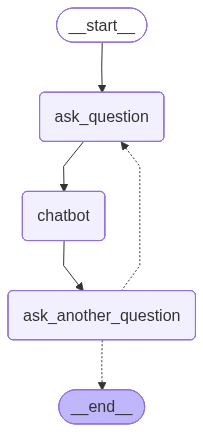

In [14]:
graph_compiled

In [15]:
print(graph_compiled.get_graph().draw_ascii())

          +-----------+       
          | __start__ |       
          +-----------+       
                 *            
                 *            
                 *            
         +--------------+     
         | ask_question |     
         +--------------+     
          ***         ..      
         *              ..    
       **                 ..  
+---------+                 . 
| chatbot |               ..  
+---------+             ..    
          ***         ..      
             *      ..        
              **   .          
     +----------------------+ 
     | ask_another_question | 
     +----------------------+ 
                 .            
                 .            
                 .            
            +---------+       
            | __end__ |       
            +---------+       


### Test the Graph

In [16]:
print("\n" + "="*50)
print(" Starting Chatbot Interaction")
print("="*50 + "\n")

result = graph_compiled.invoke(State(messages=[]))

print("\n" + "="*50)
print(" Chat session completed!")
print("="*50)



 Starting Chatbot Interaction


-------> ENTERING ask_question:
What is your question?

-------> ENTERING chatbot:
 Assistant: I think I can complete the phrase for you: "I am Batman, and men are not for killing." Is that correct?

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?

 Chat session completed!


In [17]:
print("\n" + "="*50)
print(" Enhanced Interactive Chat")
print("="*50)
print("Type 'quit' to exit\n")


chat_enhanced = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.7,
    max_tokens=200,
    timeout=60,
)

def enhanced_chatbot(state: State) -> State:
    response = chat_enhanced.invoke(state["messages"])
    print(f"\n Assistant: {response.content}")
    return State(messages=[response])

# Simple interactive loop
messages = []
while True:
    user_input = input("\n❓ You: ").strip()
    if user_input.lower() == 'quit':
        break

    messages.append(HumanMessage(content=user_input))
    response = chat_enhanced.invoke(messages)
    print(f" Assistant: {response.content}")
    messages.append(response)

print("\n Goodbye!")


 Enhanced Interactive Chat
Type 'quit' to exit

 Assistant: I think I can complete the phrase for you: "I am Batman, and men are Gotham's finest!" Or, alternatively, "I am Batman, and men are not prepared for the darkness that I will unleash!" 

However, if you're thinking of a more classic phrase, it might be: "I am vengeance, I am the night, I am Batman." 

Which one were you thinking of, or do you have a different phrase in mind?
 Assistant: I think I can complete the phrase for you: "I am Batman, and men are brave!" But I believe the classic phrase from the 1960s Batman TV show is: "I am vengeance, I am the night, I am Batman" or more fittingly: "I am Batman" from the intro, followed by the narrator saying "And men are brave" or more specifically in some versions of the show, but not in the intro:  the full quote is actually "I am Batman. And men are brave."

However the full quote actually seems to come from an episode or possibly a promo:  "And men are brave"

 Goodbye!
